In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('Agriculture_price_Mandi_dataset.csv')

**Data Cleaning of Agriculture_price_Mandi_dataset**

In [ ]:
df

,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date
0,Maharashtra,nashik,Lasalgaon(Niphad),Wheat,Maharashtra 2189,FAQ,2172.0,2399.0,2300.0,6/6/2023
1,Maharashtra,satara,Patan,Tomato,Other,FAQ,1000.0,1500.0,1250.0,6/6/2023
2,Uttar Pradesh,mainpuri,Bewar,Potato,Local,FAQ,800.0,820.0,810.0,6/6/2023
3,Rajasthan,chittorgarh,Nimbahera,Wheat,Other,FAQ,2040.0,2668.0,2300.0,6/6/2023
4,Rajasthan,pratapgarh,Pratapgarh,Onion,Other,FAQ,476.0,1043.0,617.0,6/6/2023
...,...,...,...,...,...,...,...,...,...,...
737387,Tamilnadu,namakkal,Kumarapalayam(Uzhavar Sandhai ),Potato,(Red Nanital),Local,3000.0,3500.0,3500.0,6/11/2025
737388,Orissa,dhenkanal,Kamakhyanagar,Potato,Potato,Non-FAQ,1900.0,2200.0,2000.0,6/11/2025
737389,Tamilnadu,dindigul,Vedasanthur(Uzhavar Sandhai ),Potato,(Red Nanital),Local,3500.0,4000.0,4000.0,6/11/2025
737390,Tamilnadu,virudhunagar,Virudhunagar(Uzhavar Sandhai ),Onion,Bellary,Local,2800.0,3000.0,3000.0,6/11/2025


In [ ]:
df.shape

(737392, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737392 entries, 0 to 737391
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   STATE          737392 non-null  object 
 1   District Name  737392 non-null  object 
 2   Market Name    737392 non-null  object 
 3   Commodity      737392 non-null  object 
 4   Variety        737392 non-null  object 
 5   Grade          737392 non-null  object 
 6   Min_Price      737392 non-null  float64
 7   Max_Price      737392 non-null  float64
 8   Modal_Price    737392 non-null  float64
 9   Price Date     737392 non-null  object 
dtypes: float64(3), object(7)
memory usage: 56.3+ MB


In [ ]:
df.describe()

,Min_Price,Max_Price,Modal_Price
count,737392.000000,737392.000000,737392.000000
mean,2204.849862,2659.733824,2474.484638
std,1920.977696,2145.250773,2023.851909
min,0.000000,0.000000,0.000000
25%,1100.000000,1500.000000,1300.000000
50%,2000.000000,2300.000000,2150.000000
75%,2700.000000,3205.000000,3000.000000
max,420000.000000,480000.000000,460000.000000


In [ ]:
df.isnull().sum()

,0
STATE,0
District Name,0
Market Name,0
Commodity,0
Variety,0
Grade,0
Min_Price,0
Max_Price,0
Modal_Price,0
Price Date,0


In [ ]:
df[df.duplicated()]

,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date


In [ ]:
for col in df.columns:
  if df[col].nunique() < 100:
    print(df[col].value_counts())
    print("-"*50)

STATE
Uttar Pradesh        188094
Tamilnadu             66602
Haryana               63222
Madhya Pradesh        55901
West Bengal           53927
Maharashtra           51816
Kerala                45605
Punjab                42124
Rajasthan             35785
Gujarat               26652
Himachal Pradesh      22837
Orissa                20633
Karnataka             14391
Bihar                 12454
Andhra Pradesh         9616
Jammu & Kashmir        5299
Assam                  4099
Delhi                  3713
Nagaland               3012
 Punjab                2668
Chattisgarh            2603
Chhattisgarh           2250
Manipur                1317
Chandigarh              949
Jammu and Kashmir       926
Meghalaya               810
Uttrakhand               46
Tamil Nadu               26
Tripura                  11
Gao                       4
Name: count, dtype: int64
--------------------------------------------------
Commodity
Potato    327332
Onion     298658
Wheat      76976
Tomato     26644

In [ ]:
df['STATE'].replace({'Chhattisgarh':'Chattisgarh','Jammu and Kashmir':'Jammu & Kashmir'},inplace=True)

/tmp/ipykernel_9369/3075045861.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['STATE'].replace({'Chhattisgarh':'Chattisgarh','Jammu and Kashmir':'Jammu & Kashmir'},inplace=True)


In [ ]:
df['STATE'] = df['STATE'].str.strip()

In [ ]:
for col in df.columns:
  if df[col].nunique() < 100:
    print(df[col].value_counts())
    print("-"*50)

STATE
Uttar Pradesh       188094
Tamilnadu            66602
Haryana              63222
Madhya Pradesh       55901
West Bengal          53927
Maharashtra          51816
Kerala               45605
Punjab               44792
Rajasthan            35785
Gujarat              26652
Himachal Pradesh     22837
Orissa               20633
Karnataka            14391
Bihar                12454
Andhra Pradesh        9616
Jammu & Kashmir       6225
Chattisgarh           4853
Assam                 4099
Delhi                 3713
Nagaland              3012
Manipur               1317
Chandigarh             949
Meghalaya              810
Uttrakhand              46
Tamil Nadu              26
Tripura                 11
Gao                      4
Name: count, dtype: int64
--------------------------------------------------
Commodity
Potato    327332
Onion     298658
Wheat      76976
Tomato     26644
Rice        7782
Name: count, dtype: int64
--------------------------------------------------
Variety
Other   

In [ ]:
for col in df.columns:
    count = (df[col].astype(str) != df[col].astype(str).str.strip()).sum()
    if count > 0:
        print(col, "->", count)   # check columns space is available or not

In [ ]:
df['Price Date'] = pd.to_datetime(df['Price Date'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737392 entries, 0 to 737391
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   STATE          737392 non-null  object        
 1   District Name  737392 non-null  object        
 2   Market Name    737392 non-null  object        
 3   Commodity      737392 non-null  object        
 4   Variety        737392 non-null  object        
 5   Grade          737392 non-null  object        
 6   Min_Price      737392 non-null  float64       
 7   Max_Price      737392 non-null  float64       
 8   Modal_Price    737392 non-null  float64       
 9   Price Date     737392 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(6)
memory usage: 56.3+ MB


In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f"Numerical columns identified for outlier detection: {numerical_cols}")

Numerical columns identified for outlier detection: ['Min_Price', 'Max_Price', 'Modal_Price']


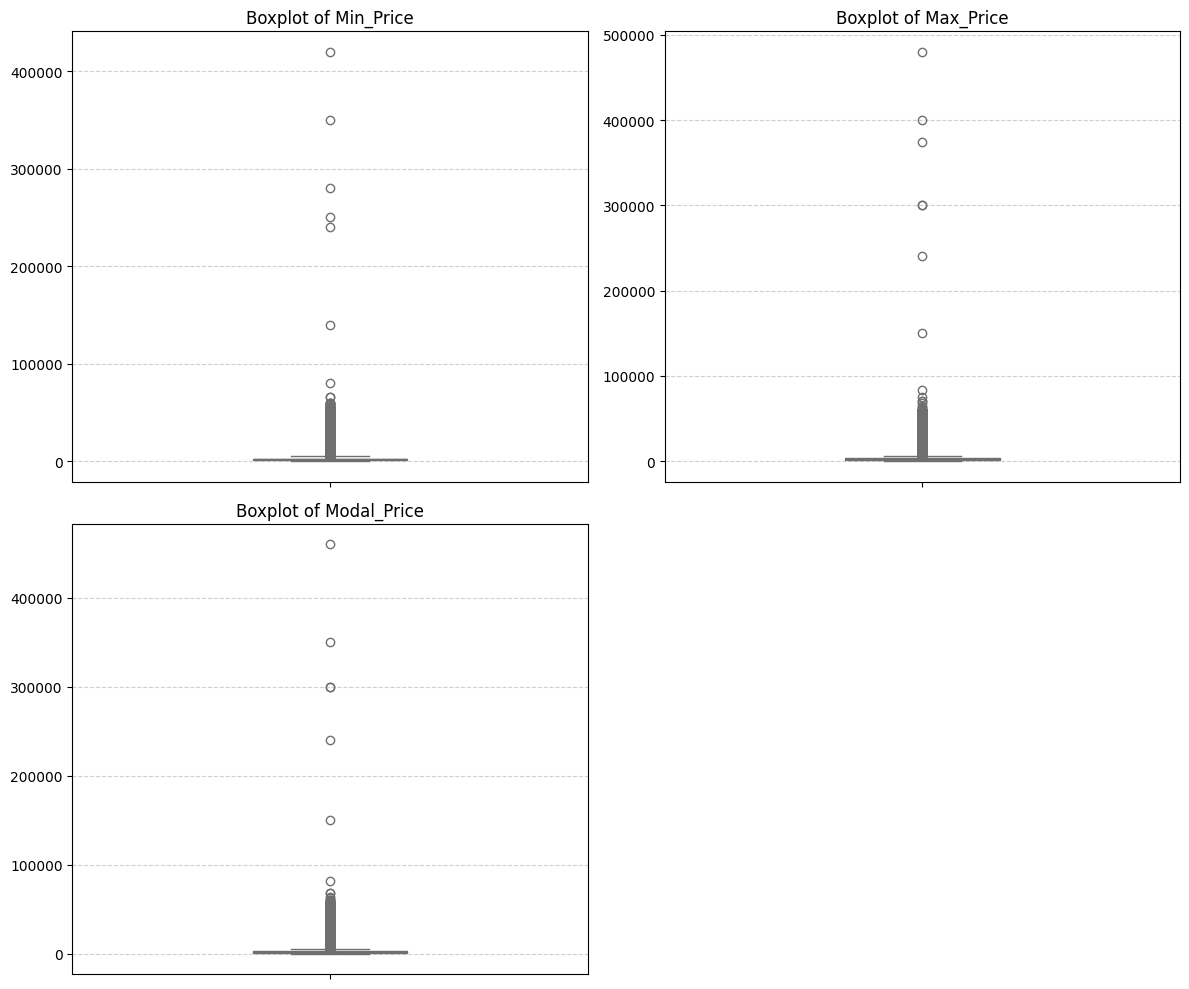

In [ ]:
cols = ['Min_Price', 'Max_Price', 'Modal_Price']

plt.figure(figsize=(12, 10)) # Adjusted figure size for 2x2 subplots
for i, col in enumerate (cols, 1):
    plt.subplot(2, 2, i) # Changed subplot layout to 2 rows, 2 columns
    sns.boxplot(y=df[col], color='skyblue', width=0.3)
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.ylabel("")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats

In [ ]:
import numpy as np
z_scores = np.abs(stats.zscore(df[['Min_Price', 'Max_Price', 'Modal_Price']]))

In [ ]:
df_clean = df[~(z_scores > 3).any(axis=1)]

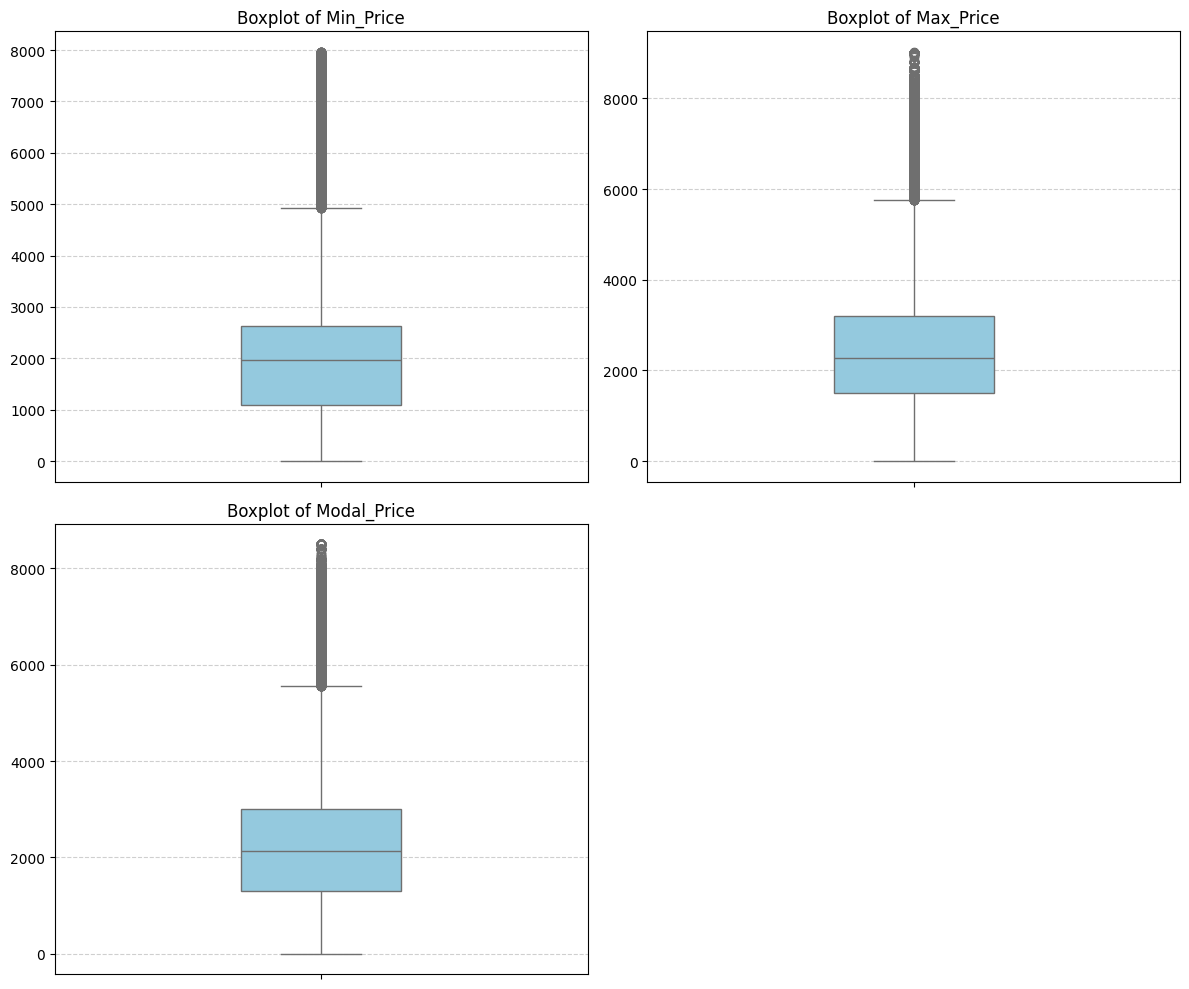

In [ ]:
cols = ['Min_Price', 'Max_Price', 'Modal_Price']

plt.figure(figsize=(12, 10)) # Adjusted figure size for 2x2 subplots
for i, col in enumerate (cols, 1):
    plt.subplot(2, 2, i) # Changed subplot layout to 2 rows, 2 columns
    sns.boxplot(y=df_clean[col], color='skyblue', width=0.3)
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.ylabel("")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Data Cleaning of Rice Vegitable price Prediction**

In [ ]:
df1=pd.read_csv('Rice_vegetable_Price_Prediction.csv')

In [ ]:
df1

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,15-01-1994,Delhi,Delhi,Delhi,934,28.67,77.22,cereals and tubers,Rice,52,KG,actual,Retail,INR,8.00,0.26
1,15-01-1994,Delhi,Delhi,Delhi,934,28.67,77.22,miscellaneous food,Sugar,97,KG,actual,Retail,INR,13.50,0.43
2,15-01-1994,Delhi,Delhi,Delhi,934,28.67,77.22,oil and fats,Oil (mustard),228,KG,actual,Retail,INR,31.00,0.99
3,15-01-1994,Gujarat,Ahmadabad,Ahmedabad,923,23.03,72.62,miscellaneous food,Sugar,97,KG,actual,Retail,INR,13.50,0.43
4,15-01-1994,Himachal Pradesh,Shimla,Shimla,963,31.10,77.17,cereals and tubers,Rice,52,KG,actual,Retail,INR,9.00,0.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146391,15-02-2026,Rajasthan,Jaipur,North Zone,9638,26.94,75.80,pulses and nuts,Lentils (masur),61,KG,actual,Retail,INR,88.01,0.97
146392,15-02-2026,Rajasthan,Jaipur,North Zone,9638,26.94,75.80,pulses and nuts,Lentils (moong),325,KG,actual,Retail,INR,109.17,1.20
146393,15-02-2026,Rajasthan,Jaipur,North Zone,9638,26.94,75.80,vegetables and fruits,Garlic,105,KG,actual,Retail,INR,38.59,0.43
146394,15-02-2026,Rajasthan,Jaipur,North Zone,9638,26.94,75.80,vegetables and fruits,Ginger,712,KG,actual,Retail,INR,24.79,0.27


In [ ]:
df1.shape

(146396, 16)

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146396 entries, 0 to 146395
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   date          146396 non-null  object 
 1   admin1        145831 non-null  object 
 2   admin2        145831 non-null  object 
 3   market        146396 non-null  object 
 4   market_id     146396 non-null  int64  
 5   latitude      145831 non-null  float64
 6   longitude     145831 non-null  float64
 7   category      146396 non-null  object 
 8   commodity     146396 non-null  object 
 9   commodity_id  146396 non-null  int64  
 10  unit          146396 non-null  object 
 11  priceflag     146396 non-null  object 
 12  pricetype     146396 non-null  object 
 13  currency      146396 non-null  object 
 14  price         146396 non-null  float64
 15  usdprice      146396 non-null  float64
dtypes: float64(4), int64(2), object(10)
memory usage: 17.9+ MB


In [ ]:
df1.describe()

,market_id,latitude,longitude,commodity_id,price,usdprice
count,146396.000000,145831.000000,145831.000000,146396.000000,146396.000000,146396.000000
mean,2439.025219,22.365736,80.194762,187.309694,93.438084,1.372066
std,2121.671166,6.229049,5.614377,121.574461,206.812128,3.516532
min,921.000000,8.510000,69.670000,52.000000,2.500000,0.057000
25%,940.000000,18.520000,76.280000,83.000000,28.000000,0.410000
50%,962.000000,23.350000,78.160000,173.000000,53.000000,0.760000
75%,4672.000000,26.640000,84.850000,325.000000,108.690000,1.500000
max,9642.000000,32.550000,94.120000,1341.000000,4910.000000,88.820000


In [ ]:
df1.isnull().sum()

,0
date,0
admin1,565
admin2,565
market,0
market_id,0
latitude,565
longitude,565
category,0
commodity,0
commodity_id,0


In [ ]:
df1.isnull().sum()/df1.shape[0]*100

,0
date,0.00000
admin1,0.38594
admin2,0.38594
market,0.00000
market_id,0.00000
latitude,0.38594
longitude,0.38594
category,0.00000
commodity,0.00000
commodity_id,0.00000


In [ ]:
df1[df1.duplicated()]

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice


In [ ]:
for col in df1.columns:
  if df1[col].nunique() < 50:
    print(df1[col].value_counts())
    print("-"*50)

admin1
Uttar Pradesh          11258
Bihar                  10359
Madhya Pradesh          9921
Tamil Nadu              8808
Orissa                  8737
Karnataka               8566
Maharashtra             7929
Rajasthan               7742
Haryana                 6508
Kerala                  6279
West Bengal             6108
Gujarat                 5742
Himachal Pradesh        5115
Punjab                  4905
Telangana               4783
Jharkhand               3997
Uttarakhand             3181
Delhi                   3175
Andhra Pradesh          3167
Meghalaya               2617
Assam                   2479
Chhattisgarh            2218
Andaman and Nicobar     1890
Nagaland                1865
Chandigarh              1717
Puducherry              1631
Tripura                 1591
Goa                     1497
Mizoram                 1360
Sikkim                   412
Manipur                  274
Name: count, dtype: int64
--------------------------------------------------
category
oil and 

In [ ]:
df1 = df1.dropna(subset=['admin1', 'admin2', 'latitude', 'longitude'])

In [ ]:
df1.isnull().sum()

,0
date,0
admin1,0
admin2,0
market,0
market_id,0
latitude,0
longitude,0
category,0
commodity,0
commodity_id,0


In [ ]:
df1.shape

(145831, 16)

In [ ]:
for col in df1.columns:
    count = (df1[col].astype(str) != df1[col].astype(str).str.strip()).sum()
    if count > 0:
        print(col, "->", count)   # check columns space is available or not

In [ ]:
df1.dtypes

,0
date,object
admin1,object
admin2,object
market,object
market_id,int64
latitude,float64
longitude,float64
category,object
commodity,object
commodity_id,int64


In [ ]:
df1['date']=pd.to_datetime(df1['date'])

/tmp/ipykernel_9369/3454300950.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df1['date']=pd.to_datetime(df1['date'])
/tmp/ipykernel_9369/3454300950.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['date']=pd.to_datetime(df1['date'])


In [ ]:
df1.dtypes

,0
date,datetime64[ns]
admin1,object
admin2,object
market,object
market_id,int64
latitude,float64
longitude,float64
category,object
commodity,object
commodity_id,int64


In [ ]:
df1.columns = [col.title() for col in df1.columns]

In [ ]:
df1.columns

Index(['Date', 'Admin1', 'Admin2', 'Market', 'Market_Id', 'Latitude',
       'Longitude', 'Category', 'Commodity', 'Commodity_Id', 'Unit',
       'Priceflag', 'Pricetype', 'Currency', 'Price', 'Usdprice'],
      dtype='object')

In [ ]:
numerical_cols = df1.select_dtypes(include=np.number).columns.tolist()
print(f"Numerical columns identified for outlier detection: {numerical_cols}")

Numerical columns identified for outlier detection: ['Market_Id', 'Latitude', 'Longitude', 'Commodity_Id', 'Price', 'Usdprice']


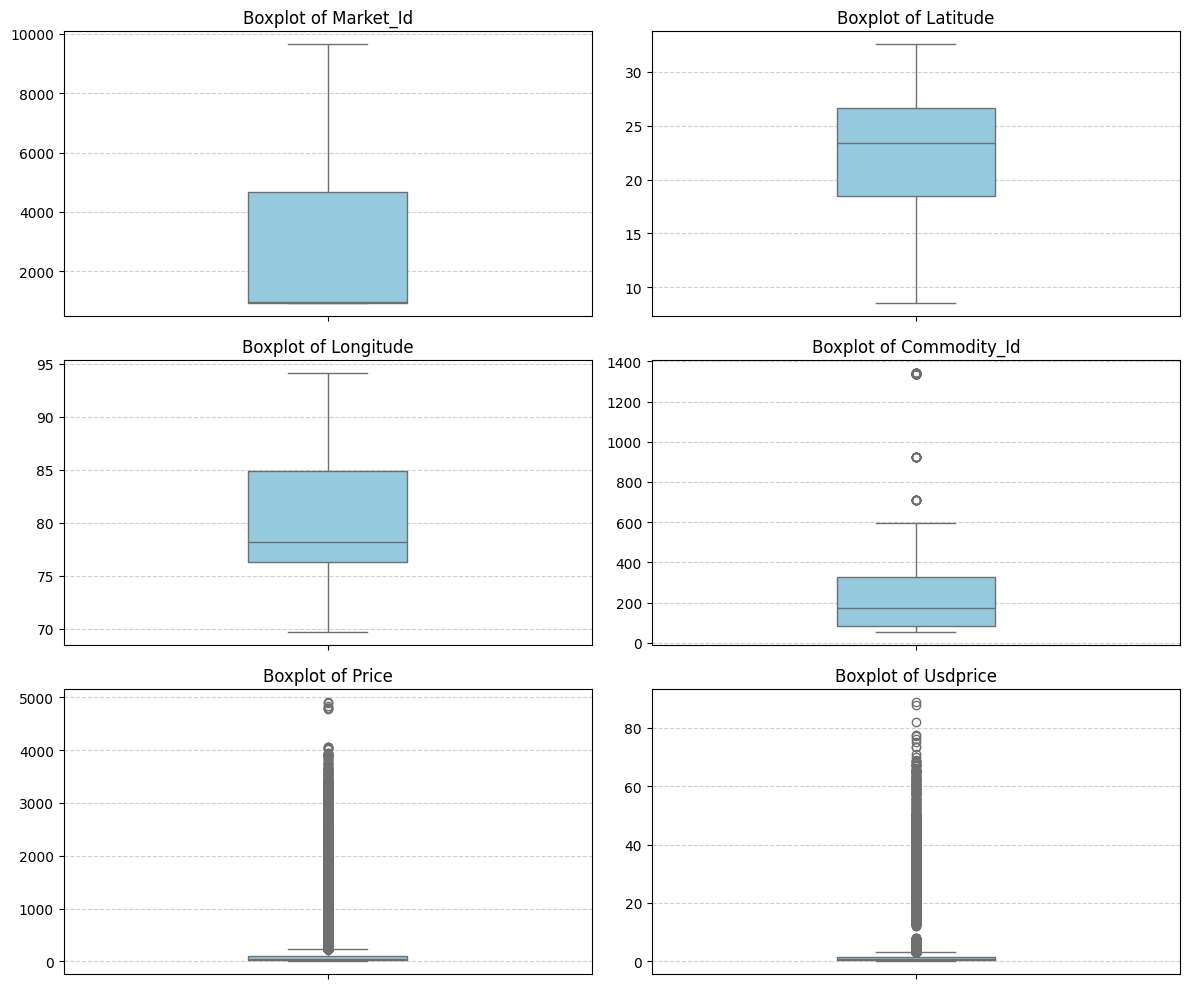

In [ ]:
cols = ['Market_Id', 'Latitude', 'Longitude', 'Commodity_Id', 'Price', 'Usdprice']

plt.figure(figsize=(12, 10)) # Adjusted figure size for 2x2 subplots
for i, col in enumerate (cols, 1):
    plt.subplot(3, 2, i) # Changed subplot layout to 3 rows, 2 columns to accommodate 6 plots
    sns.boxplot(y=df1[col], color='skyblue', width=0.3) # Changed df to df1
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.ylabel("")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats

In [ ]:
import numpy as np
z_scores = np.abs(stats.zscore(df1[['Commodity_Id', 'Price', 'Usdprice']]))

In [ ]:
df1_clean = df1[~(z_scores > 3).any(axis=1)]

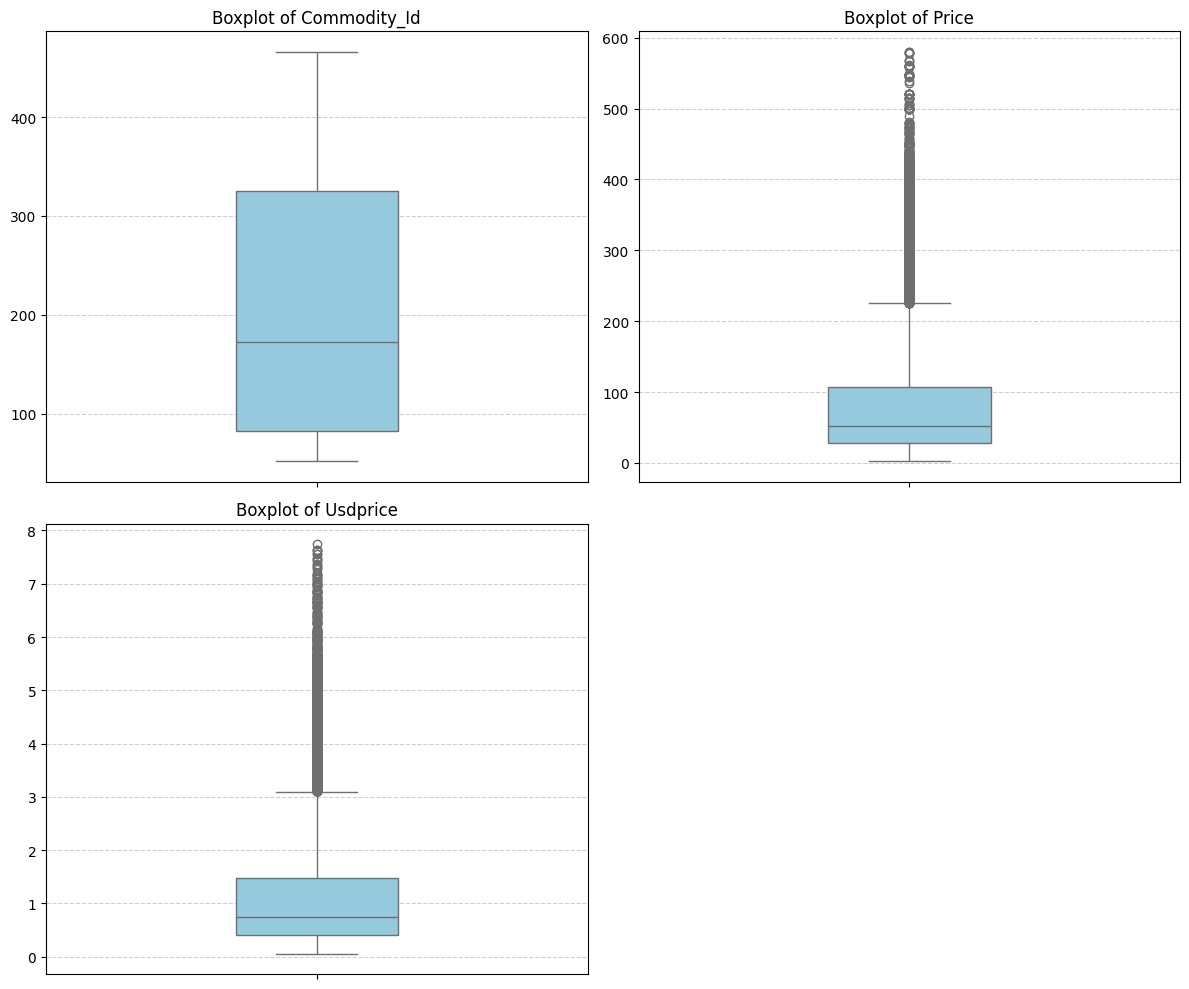

In [ ]:
cols = ['Commodity_Id', 'Price', 'Usdprice']

plt.figure(figsize=(12, 10)) # Adjusted figure size for 2x2 subplots
for i, col in enumerate (cols, 1):
    plt.subplot(2, 2, i) # Changed subplot layout to 2 rows, 2 columns
    sns.boxplot(y=df1_clean[col], color='skyblue', width=0.3) # Changed df_clean to df1_clean
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.ylabel("")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()